In [22]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [7]:
# Loading the data
data = load_wine()
X, y = data.data, data.target
feature_names = data.feature_names
class_names = data.target_names

In [11]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.3, stratify=y)

In [17]:
# Fiting
rf = RandomForestClassifier(
    n_estimators=50, #daraxtlar soni,
    max_depth=3 # daraxst chuqurligi
    )
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, n_estimators=50)

In [19]:
# Predicting
y_pred = rf.predict(X_test)
print(f"Aniqlilik: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred, target_names=class_names))

Aniqlilik: 0.9814814814814815
              precision    recall  f1-score   support

     class_0       1.00      0.94      0.97        18
     class_1       0.95      1.00      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



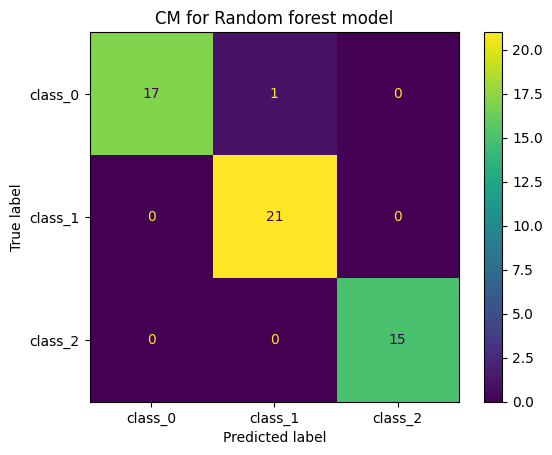

In [23]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot()
plt.title("CM for Random forest model")
plt.show()

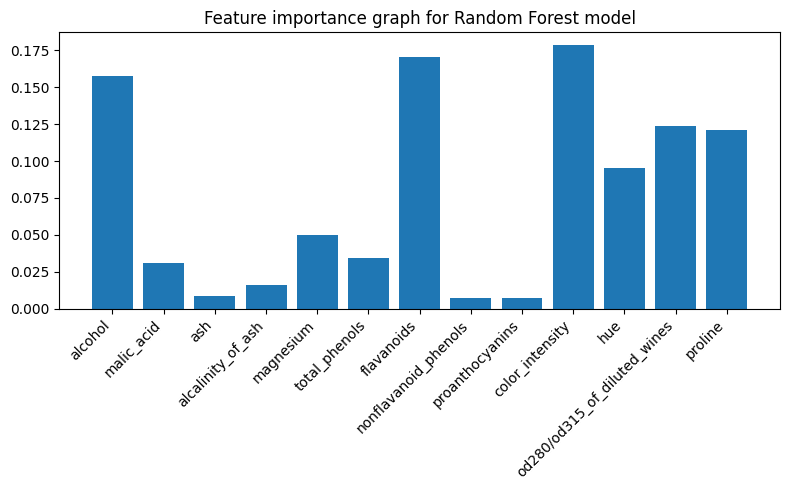

In [25]:
# Feature importance graph
plt.figure(figsize=(8, 5))
plt.bar(range(len(feature_names)), rf.feature_importances_)
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha="right")
plt.title("Feature importance graph for Random Forest model")
plt.tight_layout()
plt.show()

In [32]:
# Huddi shu datasetni GradientBoosingRegressor modeli bn fit-predct qilib ko'ramiz
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(X_train, y_train)
gbc_pred = gbc.predict(X_test)


In [34]:
# Performance measurment
print(f"Aniqlilik: {accuracy_score(y_test, gbc_pred)}")
print(classification_report(y_test, gbc_pred, target_names = class_names))

Aniqlilik: 0.9629629629629629
              precision    recall  f1-score   support

     class_0       1.00      0.89      0.94        18
     class_1       0.91      1.00      0.95        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.97        54
weighted avg       0.97      0.96      0.96        54



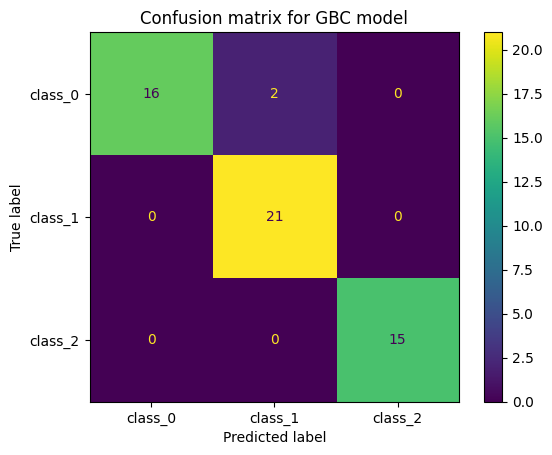

In [36]:
# Confusion report
gbc_cm = confusion_matrix(y_test, gbc_pred)
gbc_disp = ConfusionMatrixDisplay(gbc_cm, display_labels=class_names)
gbc_disp.plot()
plt.title("Confusion matrix for GBC model")
plt.show()

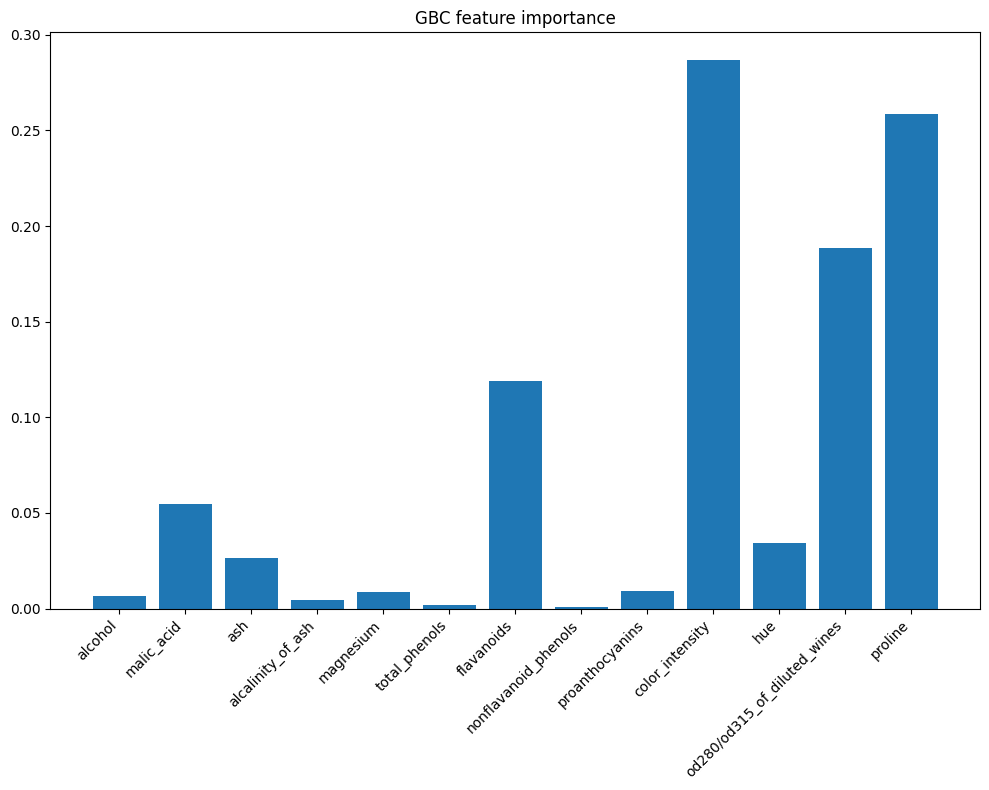

In [37]:
# Feature importance graph
plt.figure(figsize=(10, 8))
plt.bar(range(len(feature_names)), gbc.feature_importances_)
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha="right")
plt.title("GBC feature importance")
plt.tight_layout()
plt.show()

Xulosa qilib shuni aytishimiz mumkinki: Random Forest classification modeli 98% aniqlik bilan Gradient Boosting Classifier modeli (96%) ga nisbatan robustroq va yaxshiroq ekanligi aniqlandi. Feature importance graphi ham shuni ko'rsatmoqdaki Random Forest modelida alcohol classi nisbatan muhimroq class ekanligi aniqlandi.